In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
df = pd.read_csv(r"C:\Users\abdeen\Downloads\Kepler-Exoplanet-main\Kepler-Exoplanet-main\data\cumulative.csv") 
print(df.shape)          
print(df.head())
print(df.info())
print(df.describe())

(9564, 50)
   rowid     kepid kepoi_name   kepler_name koi_disposition koi_pdisposition  \
0      1  10797460  K00752.01  Kepler-227 b       CONFIRMED        CANDIDATE   
1      2  10797460  K00752.02  Kepler-227 c       CONFIRMED        CANDIDATE   
2      3  10811496  K00753.01           NaN  FALSE POSITIVE   FALSE POSITIVE   
3      4  10848459  K00754.01           NaN  FALSE POSITIVE   FALSE POSITIVE   
4      5  10854555  K00755.01  Kepler-664 b       CONFIRMED        CANDIDATE   

   koi_score  koi_fpflag_nt  koi_fpflag_ss  koi_fpflag_co  ...  \
0      1.000              0              0              0  ...   
1      0.969              0              0              0  ...   
2      0.000              0              1              0  ...   
3      0.000              0              1              0  ...   
4      1.000              0              0              0  ...   

   koi_steff_err2  koi_slogg  koi_slogg_err1  koi_slogg_err2  koi_srad  \
0           -81.0      4.467         

In [3]:
print(df['koi_disposition'].value_counts())


koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64


In [4]:
# 1. Define columns to drop (ID and non-predictive metadata)
cols_to_drop = [
    'rowid', 'kepid', 'kepoi_name', 'kepler_name', 
    'koi_pdisposition', 'koi_score',                
    'koi_tce_delivname', 'koi_tce_plnt_num'         
]
# 2. Collect all error/uncertainty columns (containing 'err')
err_columns = [col for col in df.columns if 'err' in col]
# 3. Combine drop lists
final_drop_list = cols_to_drop + err_columns
# 4. Perform the drop to clean the dataframe
df_cleaned = df.drop(columns=final_drop_list)
# 5. Define the 15 physical feature columns 
physical_features = [
    'koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration', 
    'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol', 
    'koi_model_snr', 'koi_steff', 'koi_slogg', 'koi_srad', 
    'ra', 'dec', 'koi_kepmag'
]

# 6. Final selection
df_final = df_cleaned[physical_features + ['koi_disposition']].copy()
# 8. Print Summary for confirmation
print(f"Final Shape: {df_final.shape} ")

# 9. THIS LINE TRIGGERS THE DATA VIEW ICON
df_final.head()

Final Shape: (9564, 16) 


,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag,koi_disposition
0,9.488036,170.538750,0.146,2.95750,615.8,2.26,793.0,93.59,35.8,5455.0,4.467,0.927,291.93423,48.141651,15.347,CONFIRMED
1,54.418383,162.513840,0.586,4.50700,874.8,2.83,443.0,9.11,25.8,5455.0,4.467,0.927,291.93423,48.141651,15.347,CONFIRMED
2,19.899140,175.850252,0.969,1.78220,10829.0,14.60,638.0,39.30,76.3,5853.0,4.544,0.868,297.00482,48.134129,15.436,FALSE POSITIVE
3,1.736952,170.307565,1.276,2.40641,8079.2,33.46,1395.0,891.96,505.6,5805.0,4.564,0.791,285.53461,48.285210,15.597,FALSE POSITIVE
4,2.525592,171.595550,0.701,1.65450,603.3,2.75,1406.0,926.16,40.9,6031.0,4.438,1.046,288.75488,48.226200,15.509,CONFIRMED


In [5]:
# Check missing values
print(df_final.isnull().sum())

koi_period           0
koi_time0bk          0
koi_impact         363
koi_duration         0
koi_depth          363
koi_prad           363
koi_teq            363
koi_insol          321
koi_model_snr      363
koi_steff          363
koi_slogg          363
koi_srad           363
ra                   0
dec                  0
koi_kepmag           1
koi_disposition      0
dtype: int64


In [6]:
for col in df_final.columns:
    if df_final[col].dtype != 'object': 
        if df_final[col].isnull().any():
            median_val = df_final[col].median()
            df_final[col] = df_final[col].fillna(median_val)
            print(f"{col}: filled with median = {median_val:.4f}")

# Final check 
print(f"Total missing values in df_final: {df_final.isnull().sum().sum()}")

koi_impact: filled with median = 0.5370
koi_depth: filled with median = 421.1000
koi_prad: filled with median = 2.3900
koi_teq: filled with median = 878.0000
koi_insol: filled with median = 141.6000
koi_model_snr: filled with median = 23.0000
koi_steff: filled with median = 5767.0000
koi_slogg: filled with median = 4.4380
koi_srad: filled with median = 1.0000
koi_kepmag: filled with median = 14.5200
Total missing values in df_final: 0


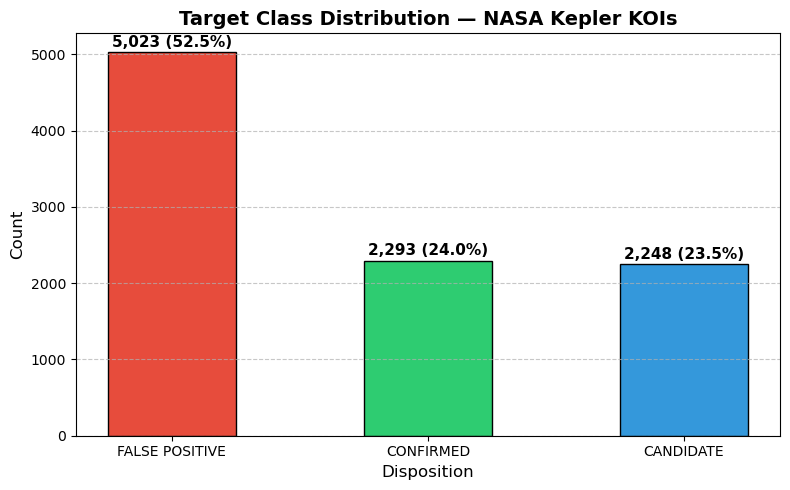

In [7]:
# Target Distribution 
counts = df_final['koi_disposition'].value_counts()

plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#2ecc71', '#3498db']
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 30,
             f'{val:,} ({val/len(df_final)*100:.1f}%)', # Changed to df_final
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("Target Class Distribution — NASA Kepler KOIs", fontsize=14, fontweight='bold')
plt.xlabel("Disposition", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Added a subtle grid for better readability
plt.tight_layout()
plt.savefig("01_target_distribution.png", dpi=150)
plt.show()

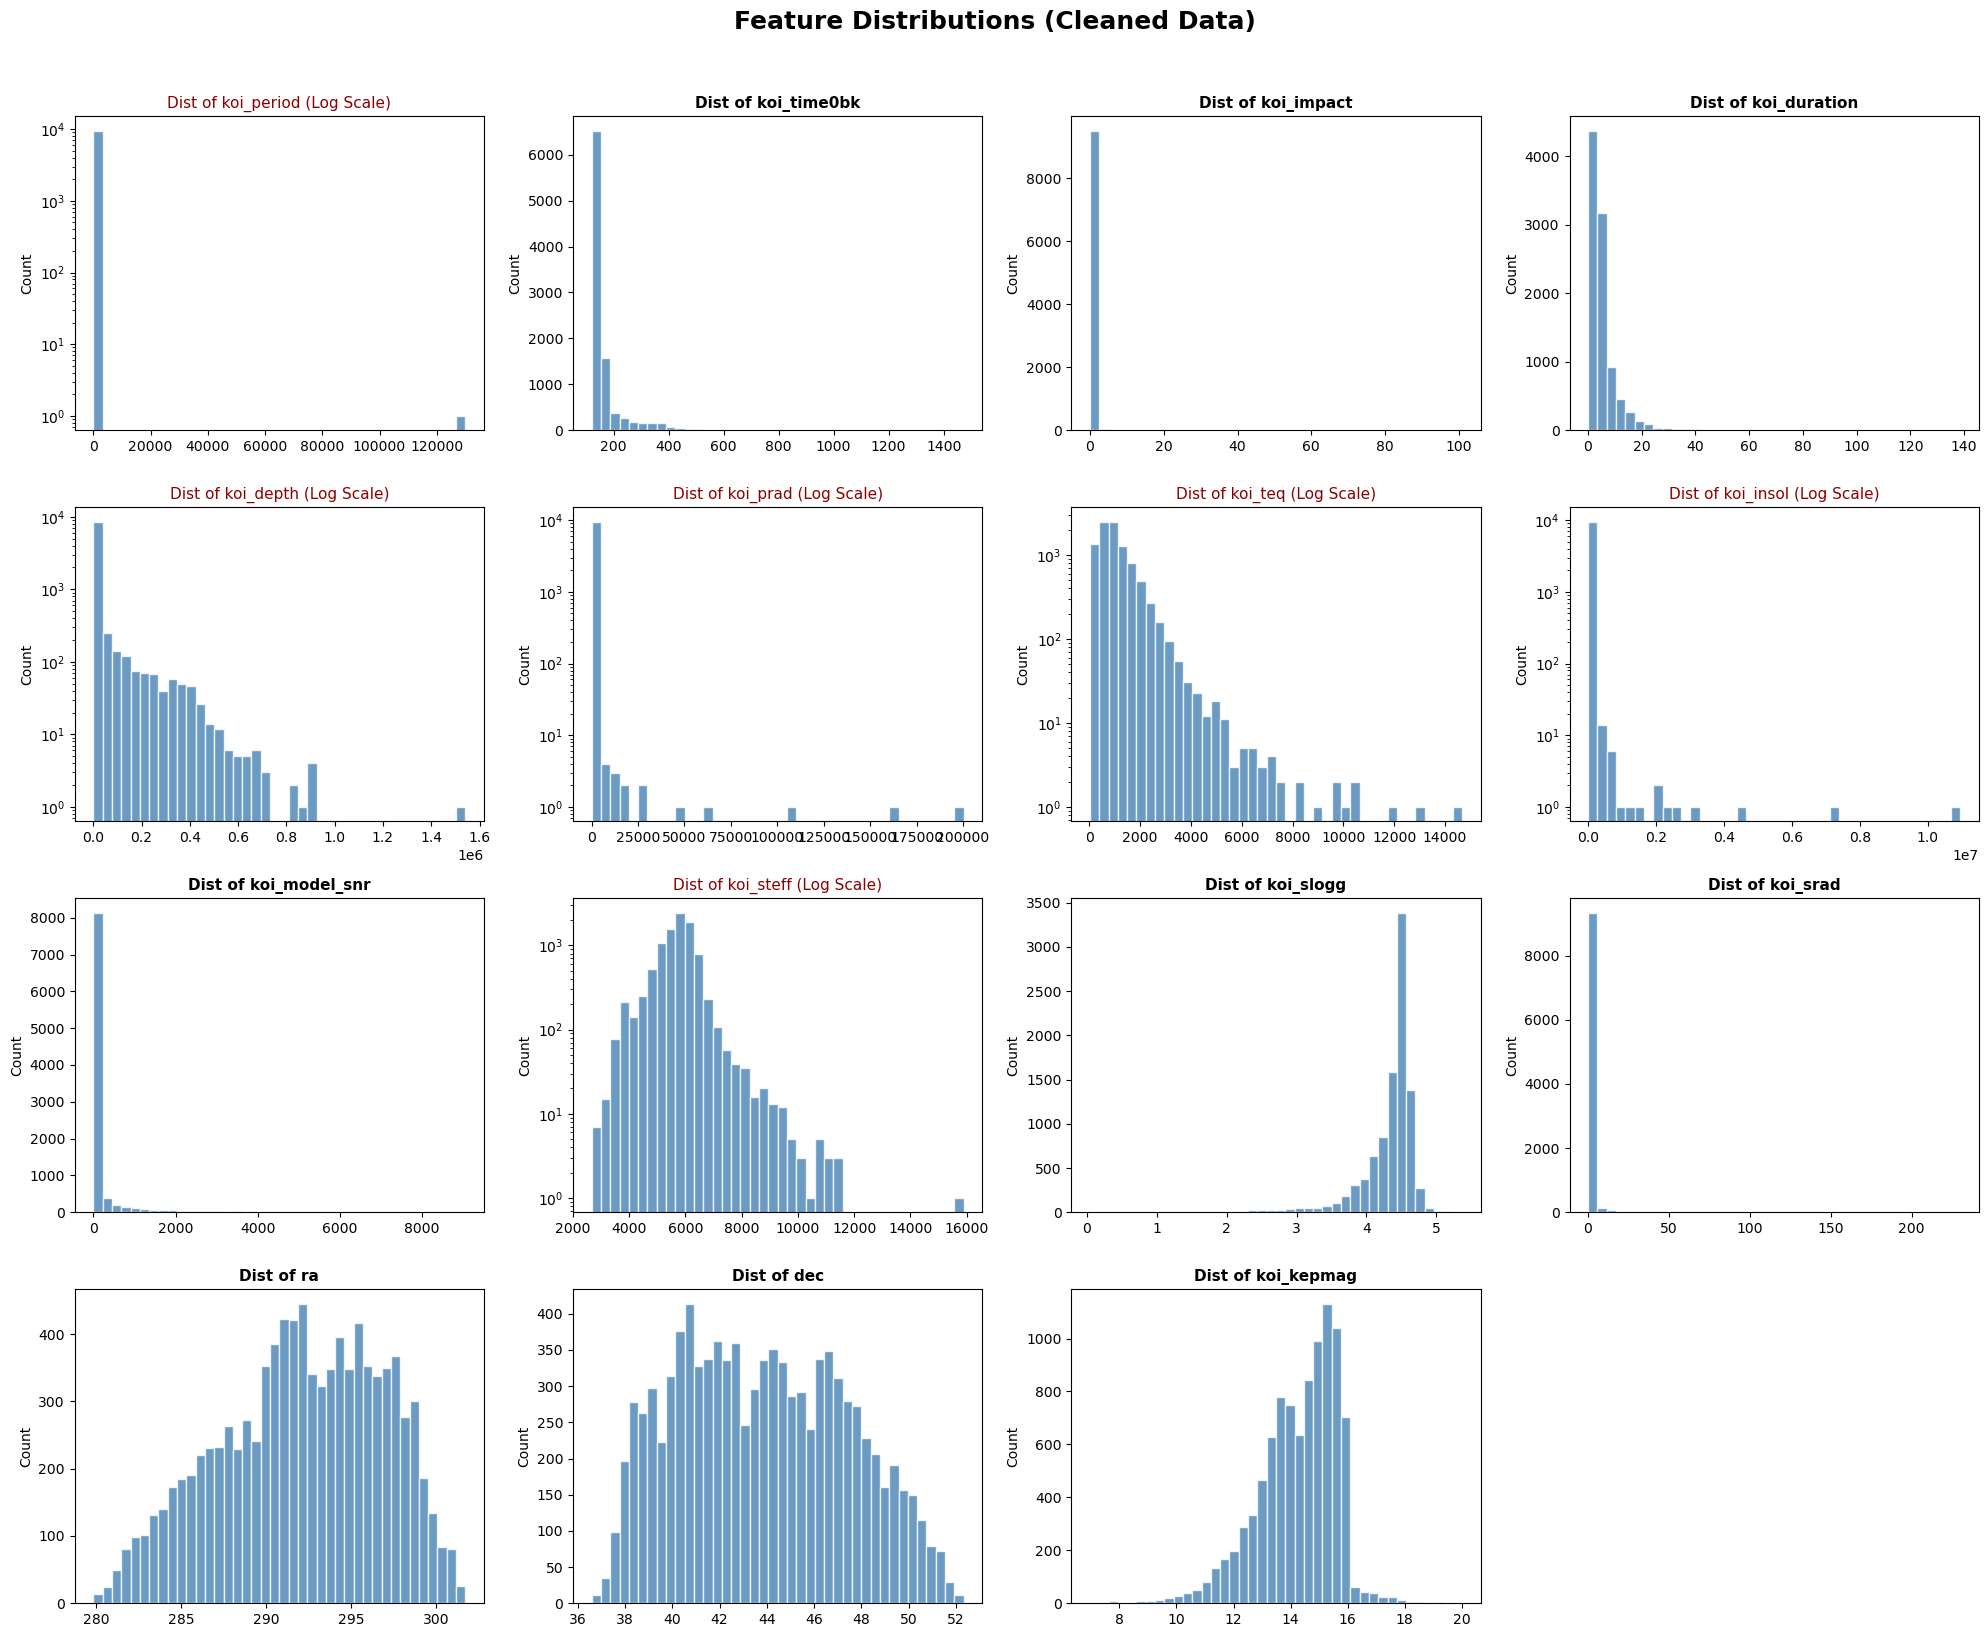

In [8]:
# EDA — Feature Distributions (Histograms) 

# 1. Define feature_cols 
feature_cols = [
    'koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration', 
    'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol', 
    'koi_model_snr', 'koi_steff', 'koi_slogg', 'koi_srad', 
    'ra', 'dec', 'koi_kepmag'
]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

# Iterate through your 15 features
for i, col in enumerate(feature_cols):
    axes[i].hist(df_final[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f"Dist of {col}", fontsize=11, fontweight='bold')
    axes[i].set_ylabel("Count")
    
    if df_final[col].max() > 10000: 
        axes[i].set_yscale('log')
        axes[i].set_title(f"Dist of {col} (Log Scale)", fontsize=11, color='darkred')

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions (Cleaned Data)", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("02_feature_distributions.png", dpi=150)
plt.show()

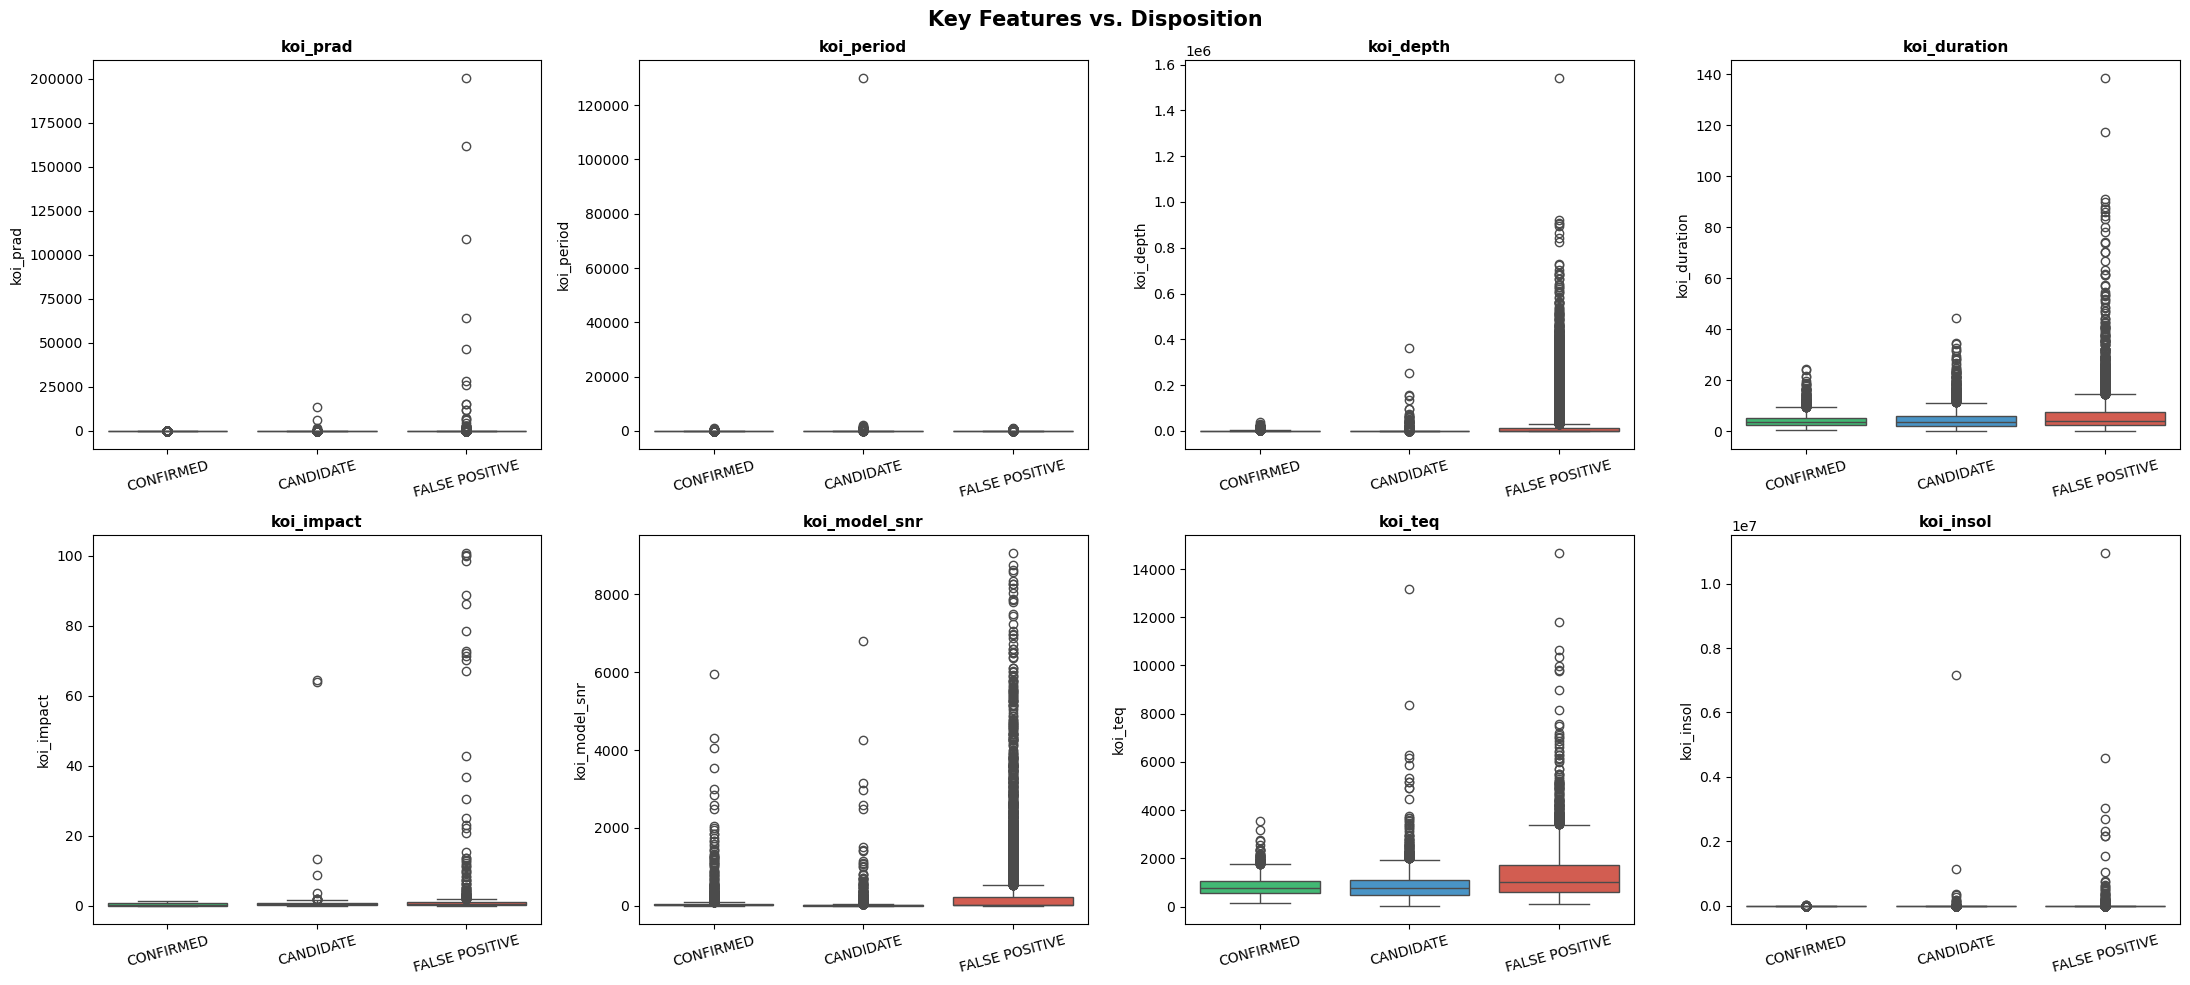

In [9]:
#  Boxplots per Class 
key_features = ['koi_prad', 'koi_period', 'koi_depth', 'koi_duration', 
                'koi_impact', 'koi_model_snr', 'koi_teq', 'koi_insol']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

palette = {'CONFIRMED': '#2ecc71', 'FALSE POSITIVE': '#e74c3c', 'CANDIDATE': '#3498db'}

for i, col in enumerate(key_features):
    sns.boxplot(x='koi_disposition', y=col, data=df_final, 
                hue='koi_disposition', palette=palette, ax=axes[i],
                order=['CONFIRMED', 'CANDIDATE', 'FALSE POSITIVE'],
                legend=False)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle("Key Features vs. Disposition", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

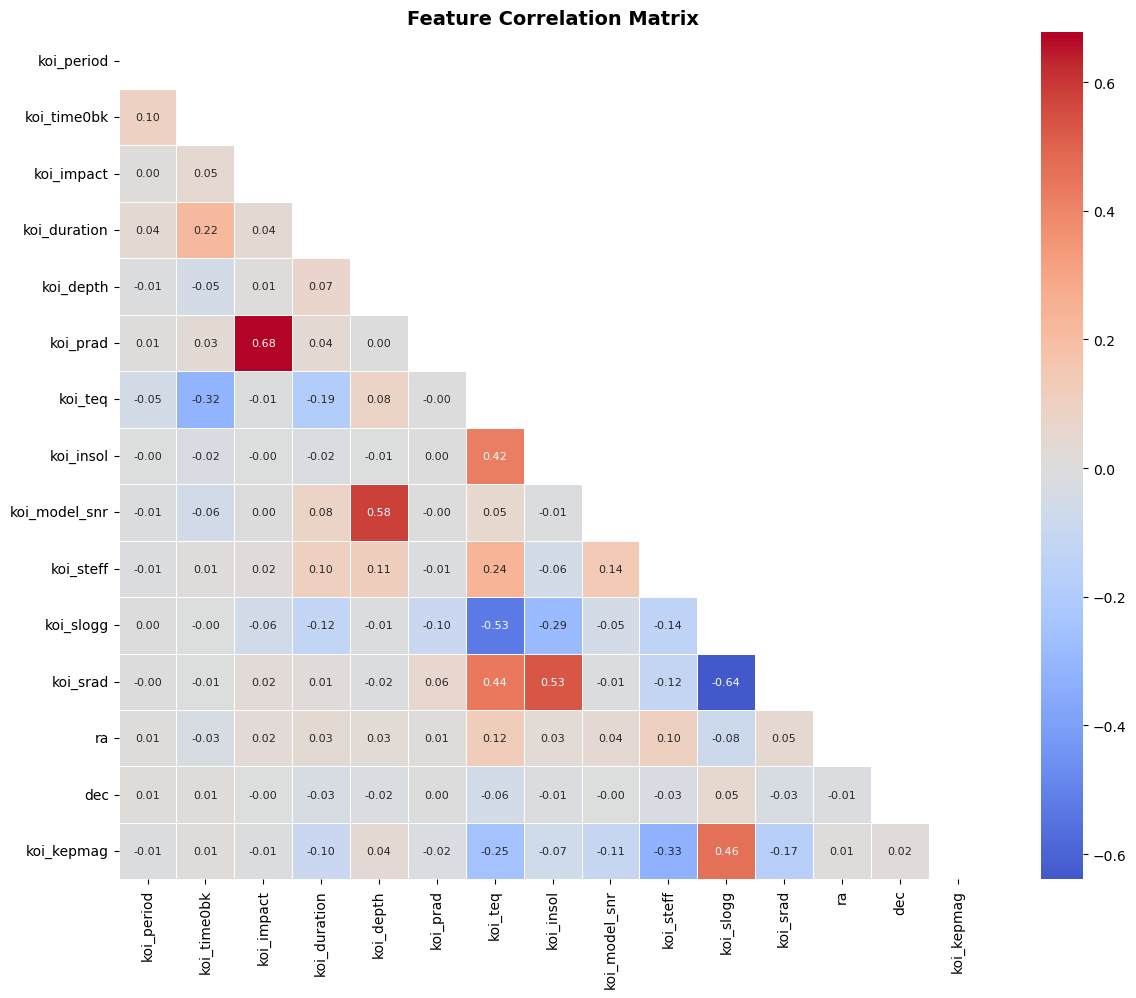

In [10]:
# Correlation Heatmap 
corr = df_final[feature_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool)) 

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            annot_kws={"size": 8}, linewidths=0.5)

plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.show()

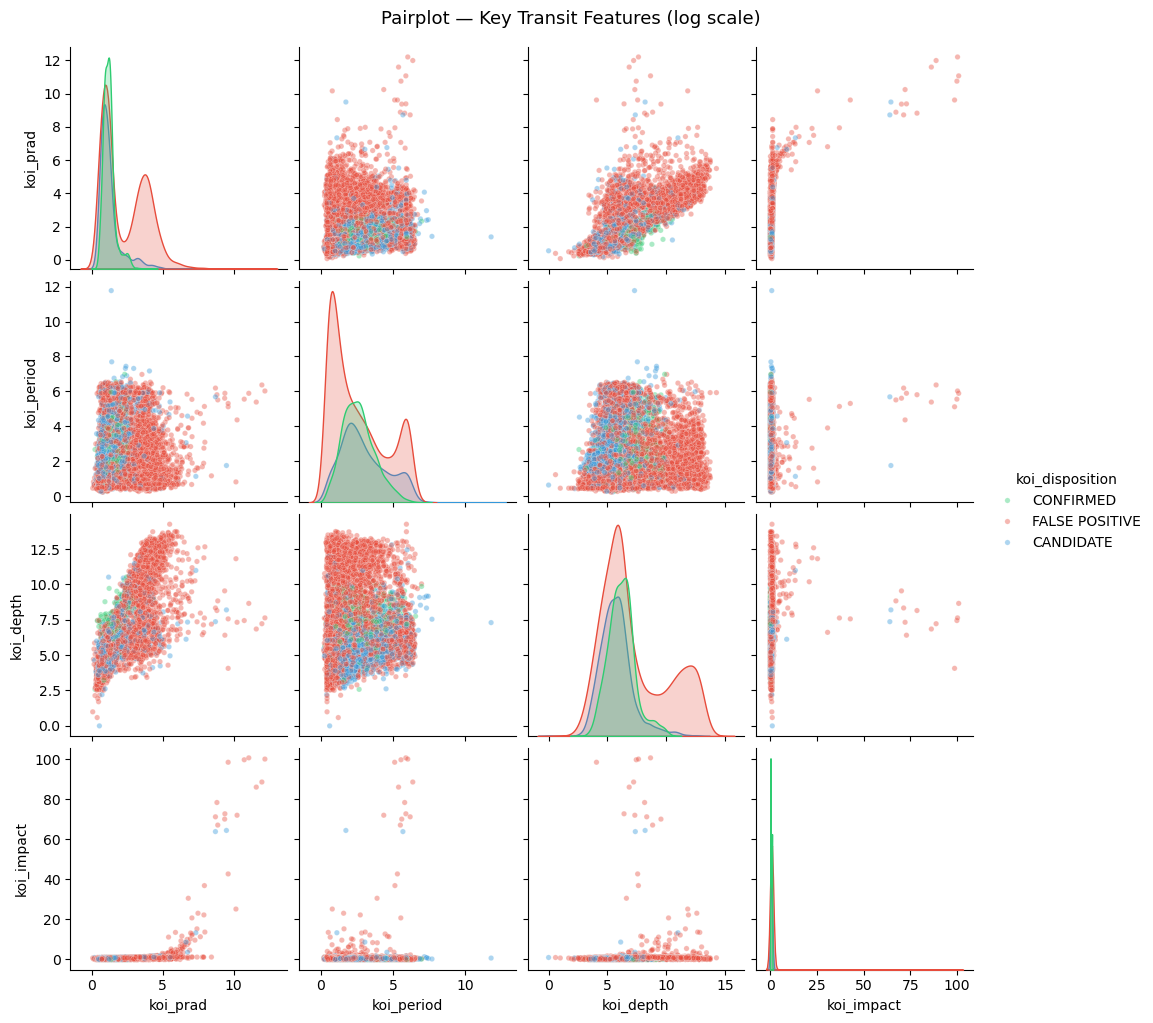

In [11]:
#  Pairplot (Top 4 Features) 
pair_features = ['koi_prad', 'koi_period', 'koi_depth', 'koi_impact', 'koi_disposition']
df_pair = df_final[pair_features].copy()

for col in ['koi_prad', 'koi_period', 'koi_depth']:
    df_pair[col] = np.log1p(df_pair[col])

g = sns.pairplot(df_pair, hue='koi_disposition', palette=palette, 
                 plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde')
g.figure.suptitle("Pairplot — Key Transit Features (log scale)", y=1.02, fontsize=13)
plt.show()

In [12]:
#  Encode Target Column 
le = LabelEncoder()
df_final['target'] = le.fit_transform(df_final['koi_disposition'])
print(f"Target Encoding Map: {dict(zip(le.classes_, le.transform(le.classes_)))}")

#  Scale Features 
scaler = StandardScaler()
X_scaled_values = scaler.fit_transform(df_final[feature_cols])
X_scaled_df = pd.DataFrame(X_scaled_values, columns=feature_cols)

Target Encoding Map: {'CANDIDATE': 0, 'CONFIRMED': 1, 'FALSE POSITIVE': 2}


In [13]:
#  Final Assembly and Save 
df_final_scaled = X_scaled_df.copy()
df_final_scaled['koi_disposition'] = df_final['koi_disposition'].values
df_final_scaled['target'] = df_final['target'].values

df_final_scaled.to_csv("cumulative_clean_scaled.csv", index=False)

print(f" Done: {df_final_scaled.shape}")

 Done: (9564, 17)


# Basic Classification

In this section, two basic classification models are applied:

1. Logistic Regression
2. Decision Tree

The goal is to classify exoplanet candidates based on the cleaned and scaled dataset prepared in the preprocessing stage.

In [14]:
# Basic Classification Imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix

In [15]:
# Use the cleaned and scaled dataframe from preprocessing
df_cls = df_final_scaled.copy()

print(df_cls.shape)
df_cls.head()

(9564, 17)


,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag,koi_disposition,target
0,-0.049588,0.064131,-0.177059,-0.411686,-0.275896,-0.032074,-0.338373,-0.047262,-0.275129,-0.325099,0.357629,-0.128771,-0.026421,1.202764,0.781320,CONFIRMED,1
1,-0.015924,-0.054029,-0.043105,-0.172241,-0.272690,-0.031885,-0.754628,-0.047802,-0.287920,-0.325099,0.357629,-0.128771,-0.026421,1.202764,0.781320,CONFIRMED,1
2,-0.041787,0.142339,0.073496,-0.593305,-0.149473,-0.027986,-0.522714,-0.047609,-0.223328,0.184093,0.538807,-0.138587,1.037397,1.200675,0.845566,FALSE POSITIVE,2
3,-0.055395,0.060727,0.166960,-0.496846,-0.183511,-0.021738,0.377585,-0.042161,0.325771,0.122683,0.585866,-0.151396,-1.369071,1.242630,0.961786,FALSE POSITIVE,2
4,-0.054804,0.079692,-0.008094,-0.613039,-0.276051,-0.031912,0.390667,-0.041943,-0.268606,0.411822,0.289393,-0.108975,-0.693454,1.226243,0.898262,CONFIRMED,1


In [16]:
# Define Features and Target
X = df_cls.drop(columns=['koi_disposition', 'target'])
y = df_cls['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print(y.value_counts())

Features shape: (9564, 15)
Target shape: (9564,)
target
2    5023
1    2293
0    2248
Name: count, dtype: int64


In [17]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (7651, 15)
X_test: (1913, 15)


In [18]:
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log, average='weighted')

print("Logistic Regression Accuracy:", log_accuracy)
print("Logistic Regression Precision:", log_precision)
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.6199686356508103
Logistic Regression Precision: 0.5601820845088917
              precision    recall  f1-score   support

           0       0.30      0.08      0.13       449
           1       0.55      0.65      0.60       459
           2       0.68      0.85      0.75      1005

    accuracy                           0.62      1913
   macro avg       0.51      0.53      0.49      1913
weighted avg       0.56      0.62      0.57      1913



In [19]:
tree_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree, average='weighted')

print("Decision Tree Accuracy:", tree_accuracy)
print("Decision Tree Precision:", tree_precision)
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.7381076842655515
Decision Tree Precision: 0.7351096127174301
              precision    recall  f1-score   support

           0       0.57      0.45      0.50       449
           1       0.68      0.87      0.77       459
           2       0.83      0.81      0.82      1005

    accuracy                           0.74      1913
   macro avg       0.69      0.71      0.70      1913
weighted avg       0.74      0.74      0.73      1913



In [20]:
# Compare Results
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [log_accuracy, tree_accuracy],
    'Precision': [log_precision, tree_precision]
})

results

,Model,Accuracy,Precision
0,Logistic Regression,0.619969,0.560182
1,Decision Tree,0.738108,0.735110


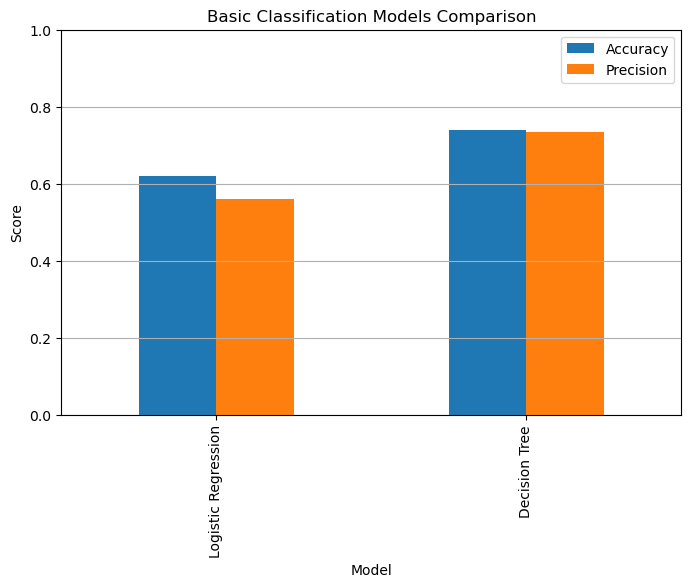

In [21]:
# Visualization of Results
results.plot(
    x='Model',
    y=['Accuracy', 'Precision'],
    kind='bar',
    figsize=(8, 5)
)

plt.title("Basic Classification Models Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

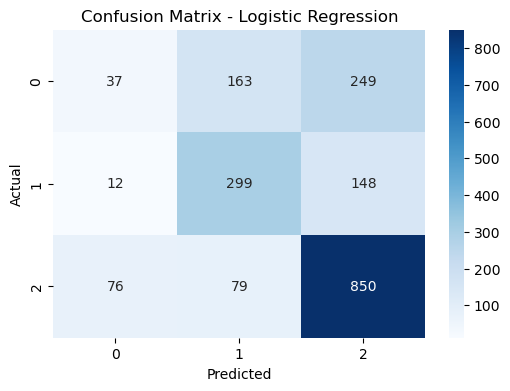

In [22]:
# Confusion Matrix for Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

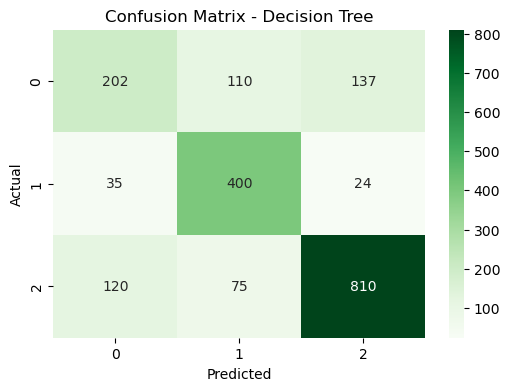

In [23]:
# Confusion Matrix for Decision Tree
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Classification Steps

1. The cleaned and scaled dataset was used.
2. Features and target variable were defined.
3. The dataset was split into training and testing sets.
4. Logistic Regression and Decision Tree models were trained.
5. The models were evaluated using Accuracy and Precision.

## Results Analysis

The Logistic Regression model achieved moderate performance, as it is a linear model and may struggle with complex patterns in the data.

On the other hand, the Decision Tree model performed significantly better, indicating that the dataset contains non-linear relationships that are better captured by tree-based models.

Some classes are harder to predict due to overlapping feature distributions and moderate class imbalance.

## Model Comparison

The Decision Tree model clearly outperformed Logistic Regression in both Accuracy and Precision.

- Logistic Regression Accuracy: ~62%
- Decision Tree Accuracy: ~74%

This shows that non-linear models are more suitable for this dataset compared to linear models.

## Conclusion

Basic classification models provide a strong baseline for the problem.

However, more advanced models such as Support Vector Machines (SVM) and Naive Bayes are expected to further improve performance.

These advanced techniques will be explored in the next stage of the project.